  [entropy] gpqa_llama_3b: using 'entropy_value', correct='model_answer_correct'
  [entropy] gpqa_llama_70b: using 'entropy_value', correct='model_answer_correct'

[gpqa] student=llama_3b  teacher=llama_70b  n=546
  S.acc=0.282  T.acc=0.515  HV=33.2%  Noisy=48.5%

  RANKING TABLE — top 5%   [gpqa | llama_3b → llama_70b]
  Metric       HV%   ConfNoise%   UncNoise%   S.Acc   T.Acc   Lift HV
-------------------------------------------------------------------------------------------------------------------
  1. Window-Ratio   51.9%         3.7%        0.0%    44.4%    96.3%      +7.7%
  2. Window-Log (IDS)   51.9%         3.7%        0.0%    44.4%    96.3%      +7.7%
  3. Random   48.1%        33.3%        3.7%    29.6%    63.0%   baseline
  4. ER       44.4%        40.7%        0.0%    29.6%    59.3%      -7.7%
  5. EG       37.0%        48.1%        0.0%    25.9%    51.9%     -23.1%
  6. LI       33.3%        51.9%        0.0%    29.6%    48.1%     -30.8%
  7. H        29.6%        51.9%

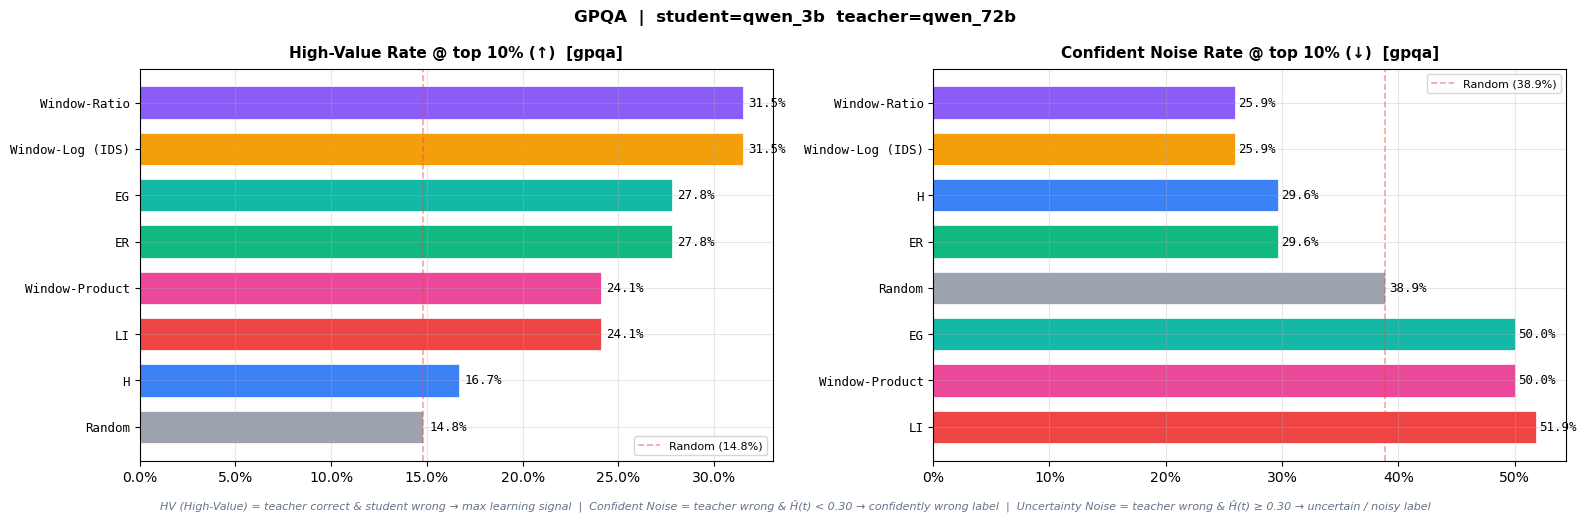

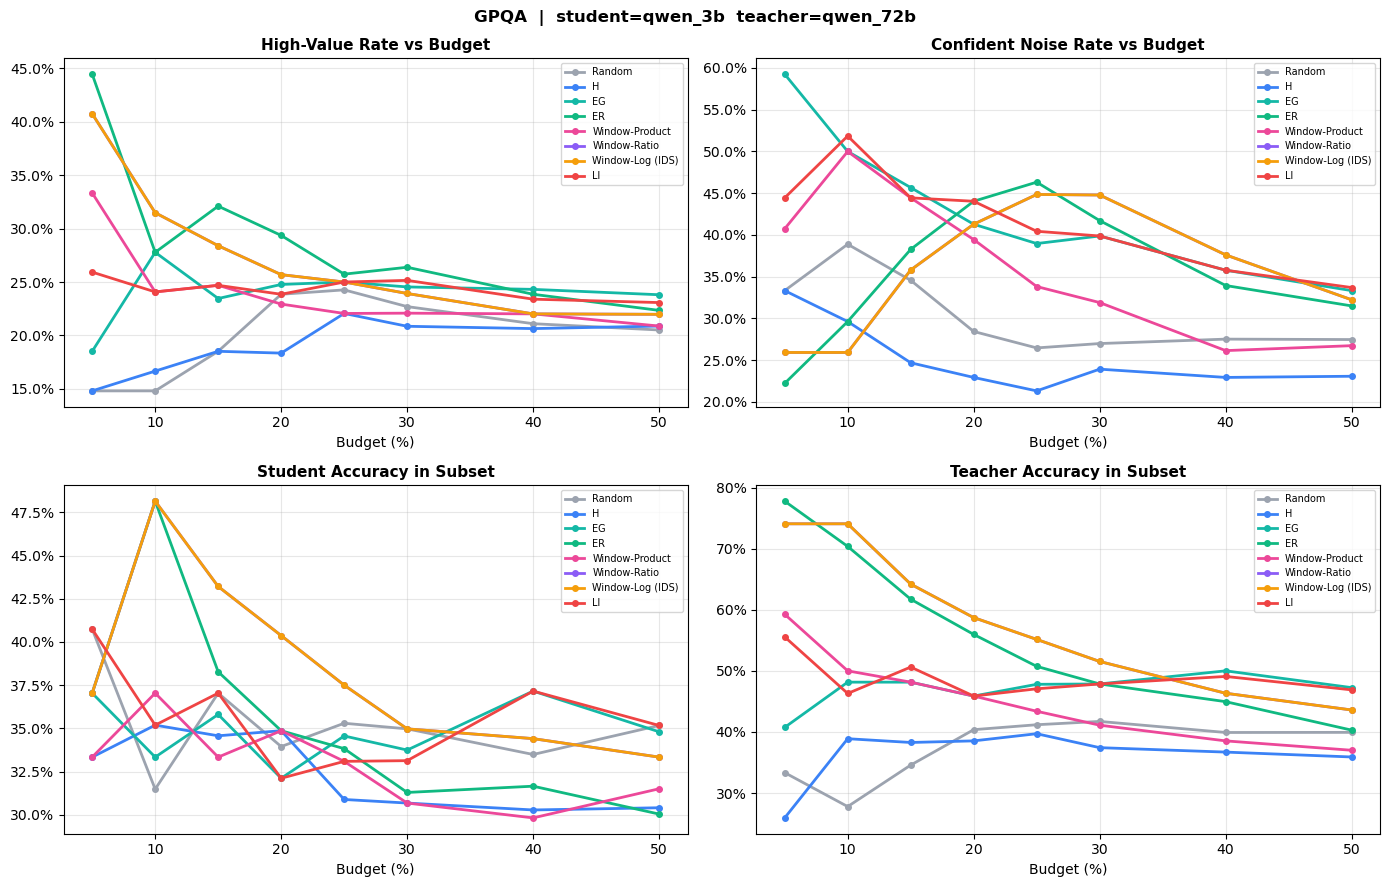

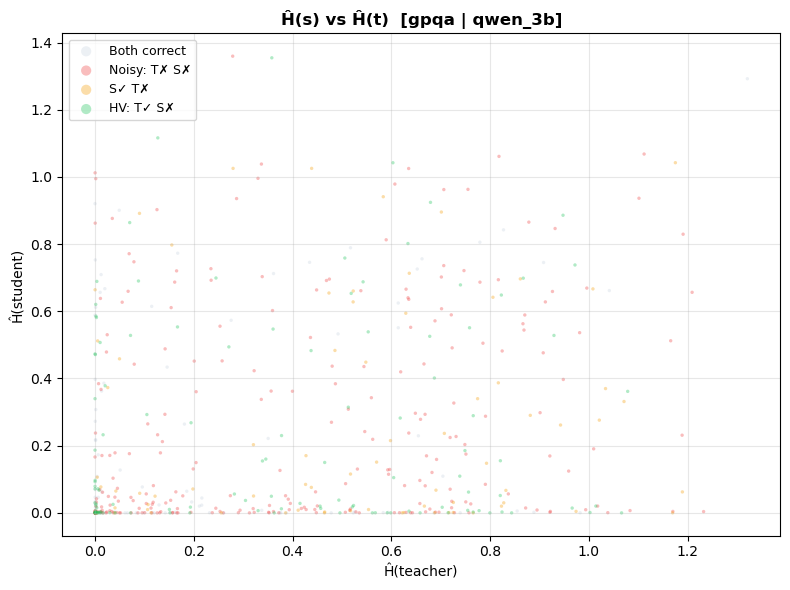


[plots] gsm8k: student=qwen_3b  teacher=qwen_72b
  [entropy] gsm8k_qwen_3b: using 'first_token_entropy', correct='model_answer_correct'
  [entropy] gsm8k_qwen_72b: using 'first_token_entropy', correct='model_answer_correct'


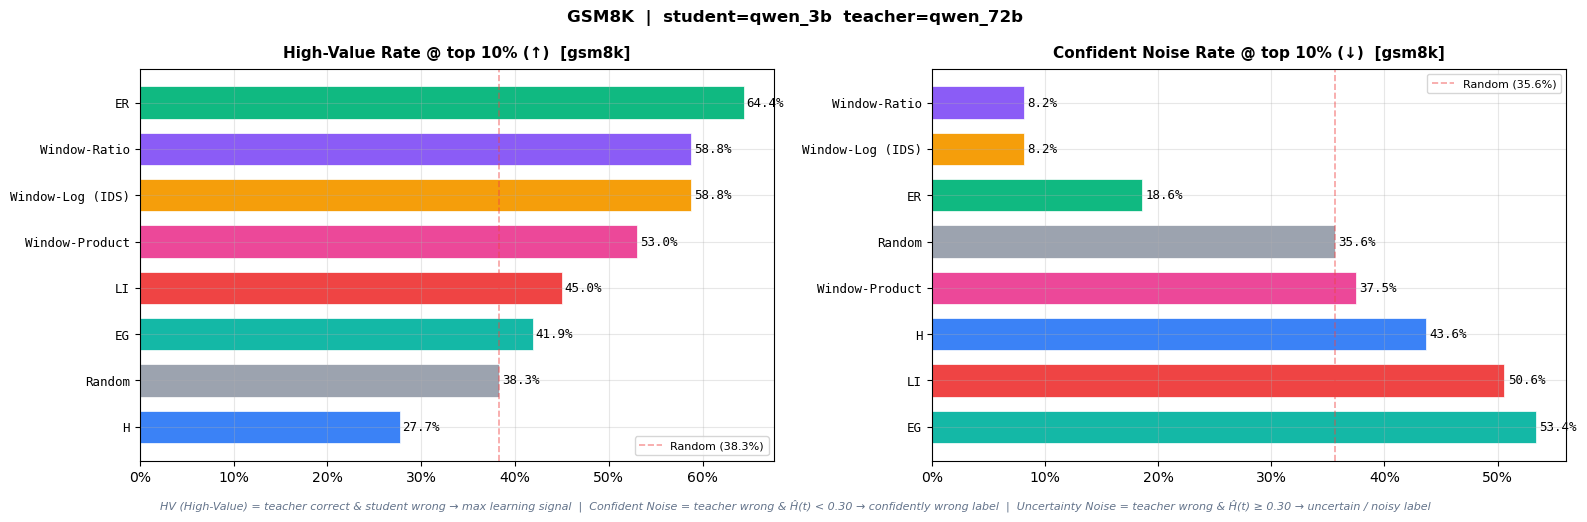

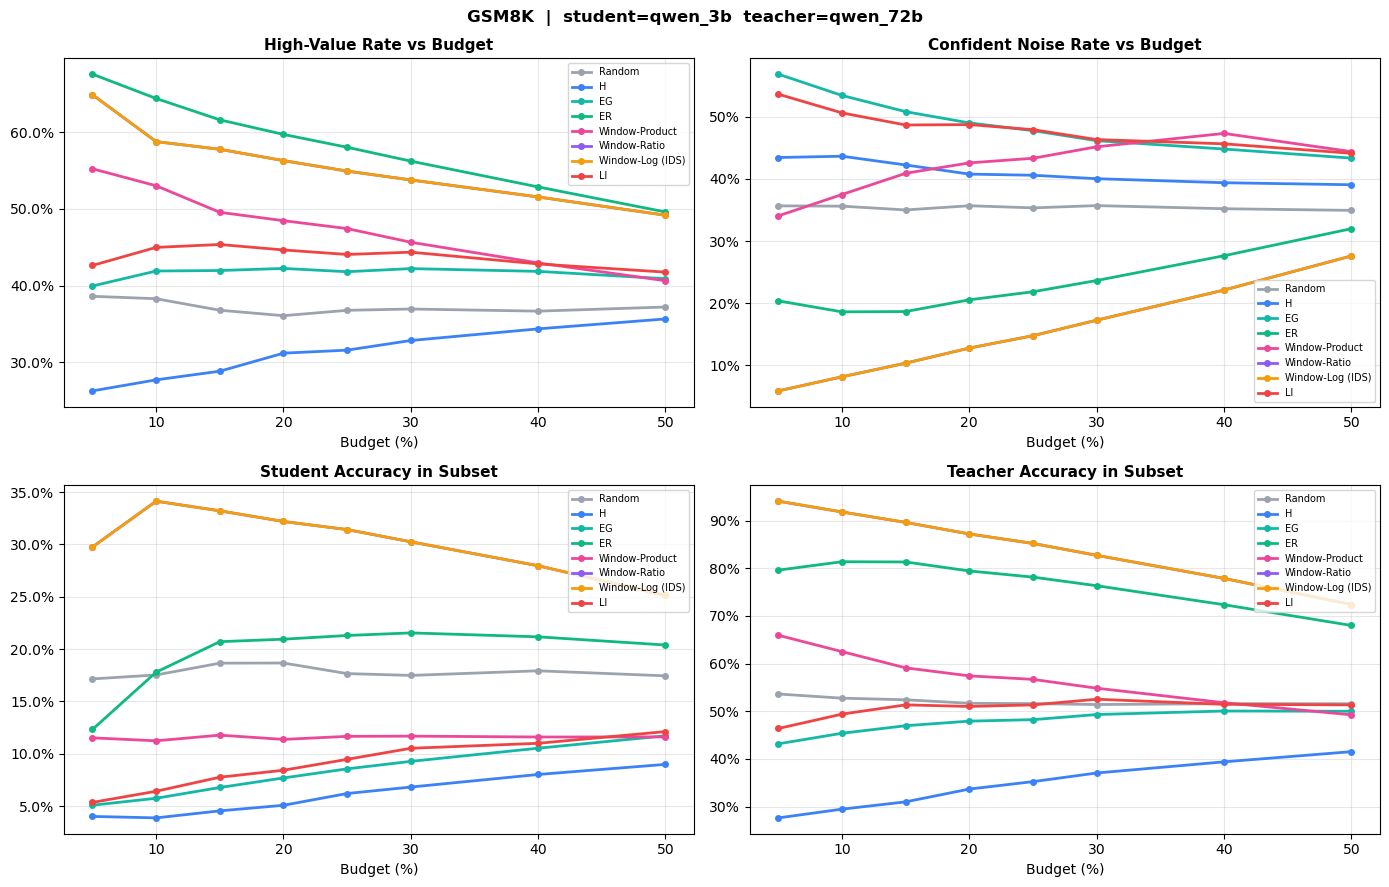

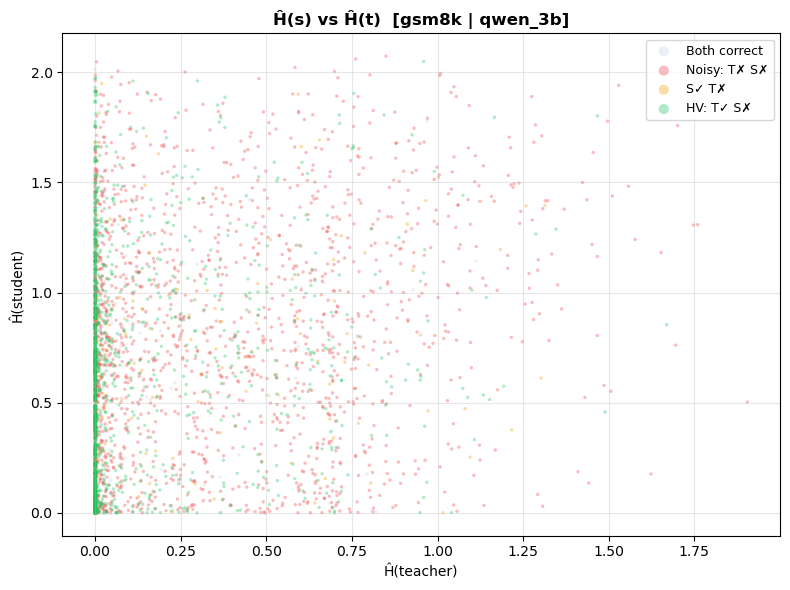


[plots] mmlu: student=qwen_3b  teacher=qwen_72b
  [entropy] mmlu_qwen_3b: using 'entropy_value', correct='model_answer_correct'
  [entropy] mmlu_qwen_72b: using 'entropy_value', correct='model_answer_correct'


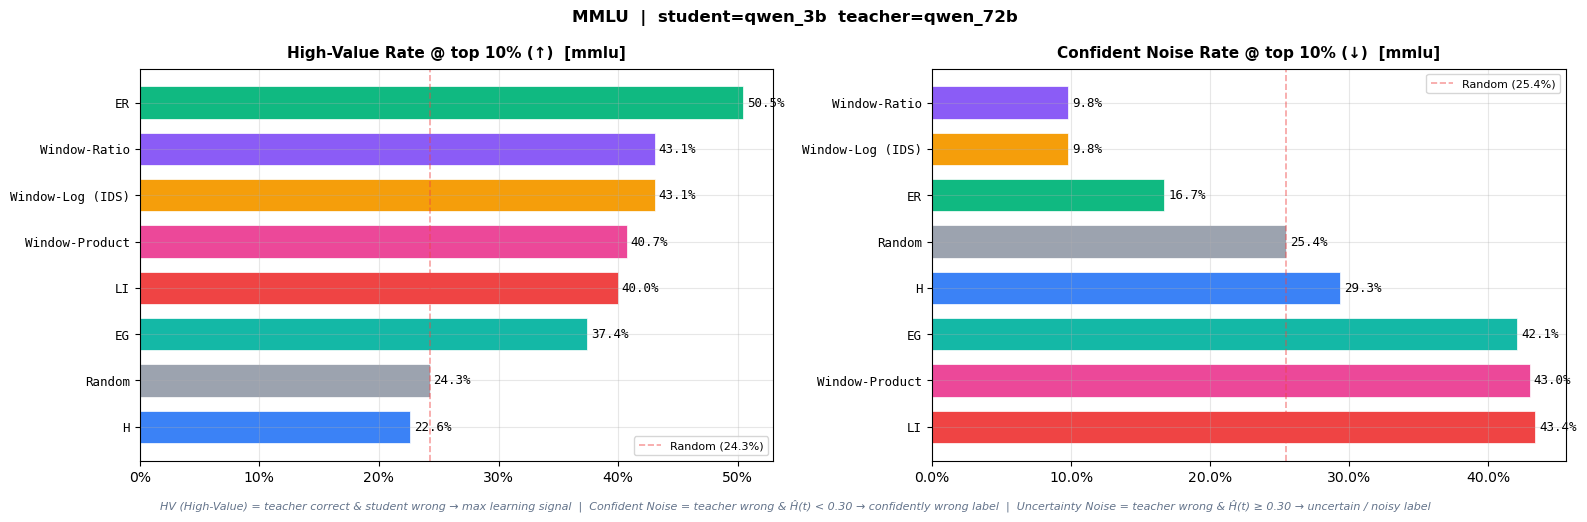

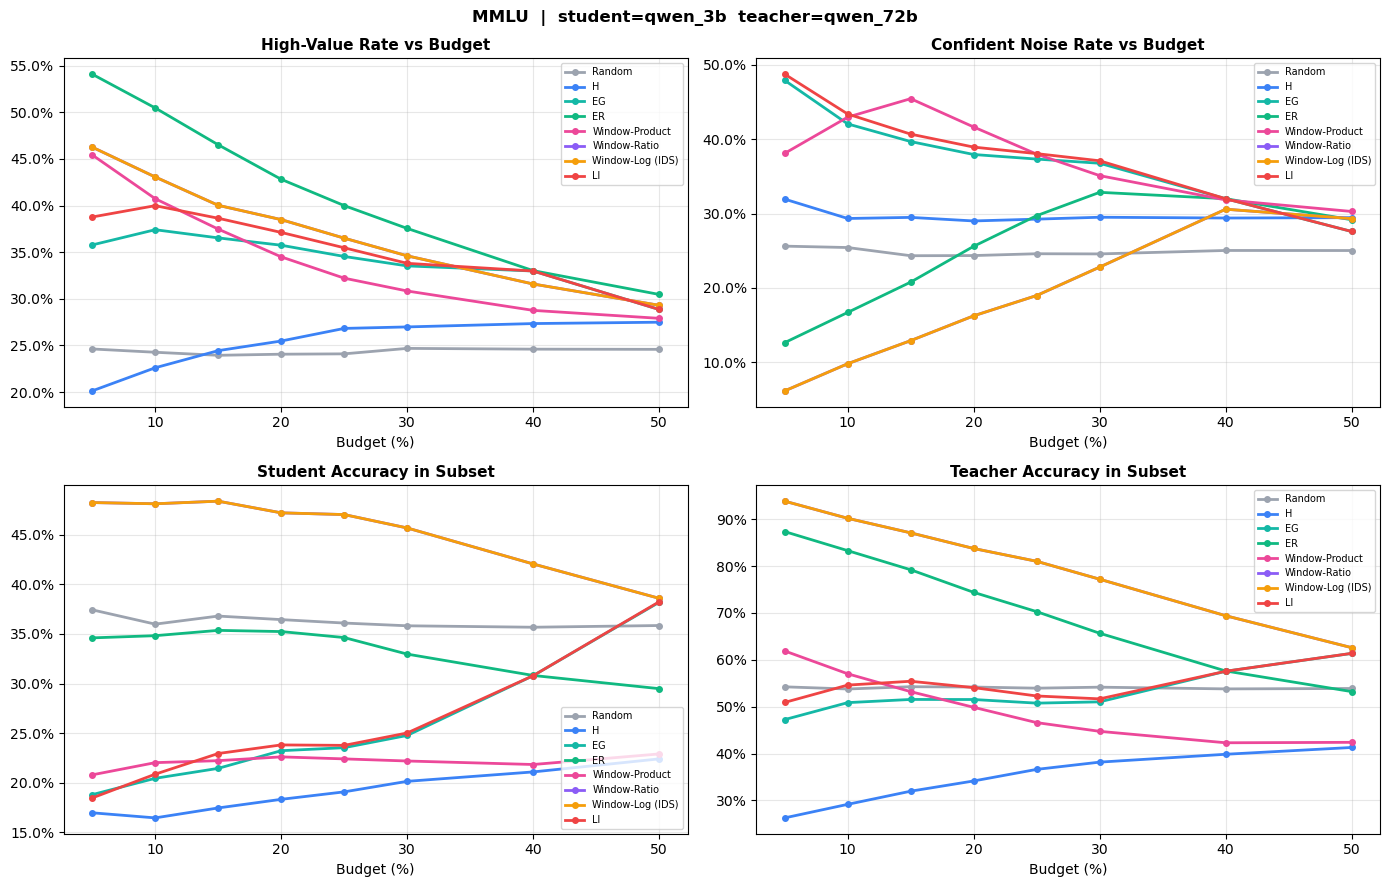

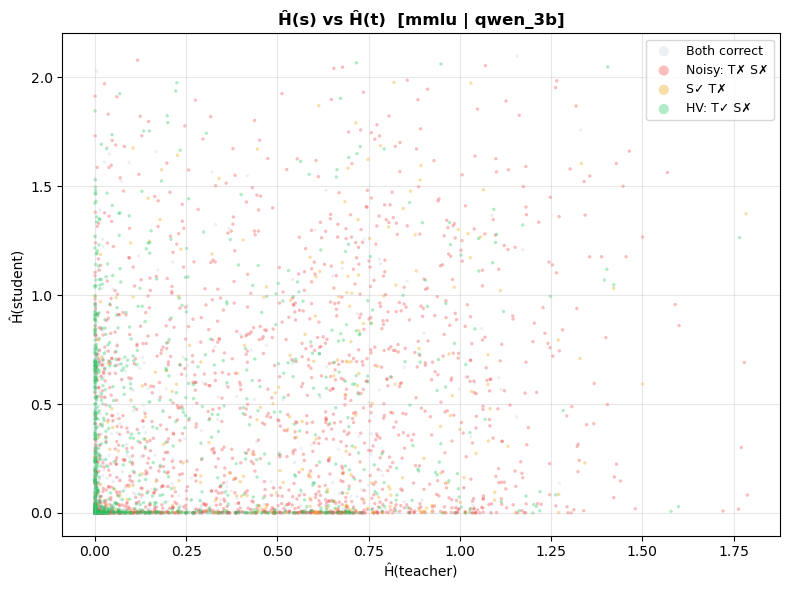


✓  All figures saved.
✓  Done.


In [23]:
"""
Active Learning Metrics — multi-dataset, multi-model full analysis
Datasets: gpqa, gsm8k, mmlu
Metrics : Random | H | EG (ex-BALD+) | ER (ex-SNR)
Entropy : max-normalised only
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────
DATA_DIR  = "./"          # ← folder with all *.parquet files
K_EVAL    = 0.10          # default evaluation budget
K_FRACS   = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
EPS       = 1e-8
CONF_THR  = 0.30          # Ĥ(t) threshold: below → confident teacher

# Available models per dataset  (order doesn't matter)
# small models (≤5B) → students | large models (>5B) → teachers
# large_llm_combined is excluded entirely
STUDENTS = ["llama_3b", "phi4mini", "qwen_3b"]
TEACHERS  = ["llama_70b", "mistral_24b", "qwen_32b", "qwen_72b"]

DATASETS = {
    "gpqa":  {"students": STUDENTS,
              "teachers": ["llama_70b", "mistral_24b", "qwen_32b", "qwen_72b"]},
    "gsm8k": {"students": STUDENTS,
              "teachers": ["llama_70b", "mistral_24b", "qwen_32b", "qwen_72b"]},
    "mmlu":  {"students": STUDENTS,
              "teachers": ["llama_70b", "mistral_24b", "qwen_32b", "qwen_72b"]},
}

# Explicit student-teacher pair to use for plots (one per dataset).
# Change these to any valid (student, teacher) combination from DATASETS above.
PLOT_PAIRS = {
    "gpqa":  ("qwen_3b", "qwen_72b"),
    "gsm8k": ("qwen_3b", "qwen_72b"),
    "mmlu":  ("qwen_3b", "qwen_72b"),
}

METRIC_COLORS = {
    "Random":           "#9ca3af",
    "H":                "#3b82f6",
    "EG":               "#14b8a6",
    "ER":               "#10b981",
    "Window-Product":   "#ec4899",
    "Window-Ratio":     "#8b5cf6",
    "Window-Log (IDS)": "#f59e0b",
    "LI":               "#ef4444",
}

DEFINITIONS = (
    "HV (High-Value) = teacher correct & student wrong → max learning signal  |  "
    "Confident Noise = teacher wrong & Ĥ(t) < 0.30 → confidently wrong label  |  "
    "Uncertainty Noise = teacher wrong & Ĥ(t) ≥ 0.30 → uncertain / noisy label"
)

# ──────────────────────────────────────────────────────────────────────────────
# DATA LOADING
# ──────────────────────────────────────────────────────────────────────────────


def load_model(dataset: str, model: str) -> pd.DataFrame:
    """Load parquet, return standardised 3-column frame: question_id, H, correct.

    Entropy priority: first_token_entropy (if present) → entropy_value.
    """
    path = os.path.join(DATA_DIR, f"{dataset}_{model}.parquet")
    df = pd.read_parquet(path)

    if "first_token_entropy" in df.columns:
        ent_col = "first_token_entropy"
    elif "entropy_value" in df.columns:
        ent_col = "entropy_value"
    elif "distill_entropy" in df.columns:
        ent_col = "distill_entropy"
    else:
        raise KeyError(
            f"{dataset}_{model}: no entropy column found. "
            f"Available columns: {list(df.columns)}"
        )

    # distill_entropy files use distill_ans_correct instead of model_answer_correct
    cor_col = "distill_ans_correct" if "model_answer_correct" not in df.columns else "model_answer_correct"

    print(f"  [entropy] {dataset}_{model}: using '{ent_col}', correct='{cor_col}'")

    out = df[["question_id", ent_col, cor_col]].copy()
    out = out.rename(columns={ent_col: "entropy_value", cor_col: "model_answer_correct"})
    out["entropy_value"] = out["entropy_value"].astype(float)
    return out


def build_pair(dataset: str, student: str, teacher: str) -> pd.DataFrame:
    """Inner-join student and teacher frames on question_id."""
    s = load_model(dataset, student).rename(
            columns={"entropy_value": "H_s", "model_answer_correct": "student_correct"})
    t = load_model(dataset, teacher).rename(
            columns={"entropy_value": "H_t", "model_answer_correct": "teacher_correct"})
    df = s.merge(t, on="question_id").copy()
    df["student_correct"] = df["student_correct"].astype(bool)
    df["teacher_correct"] = df["teacher_correct"].astype(bool)
    return df

# ──────────────────────────────────────────────────────────────────────────────
# METRICS  (max-normalised entropies only)
# ──────────────────────────────────────────────────────────────────────────────

def get_metric_scores(df: pd.DataFrame):
    """Return dict of score arrays + normalised entropy arrays."""
    H_s = df["H_s"].values.astype(float)
    H_t = df["H_t"].values.astype(float)
    Hs_n = H_s / (H_s.max() + EPS)
    Ht_n = H_t / (H_t.max() + EPS)

    rng = np.random.RandomState(42)
    Hs_var = Hs_n * (1 - Hs_n)   # Fisher Information signal term
    # P_t proxy: teacher confidence ≈ 1 - Ĥ(t)
    Pt_proxy = 1 - Ht_n
    scores = {
        "Random":           rng.rand(len(df)),
        "H":                Hs_n,
        "EG":               np.maximum(Hs_n - Ht_n, 0),          # formerly BALD+
        "ER":               Hs_n**2 / np.maximum(Ht_n**2, EPS),  # formerly SNR
        "Window-Product":   Hs_var * (1 - Ht_n),
        "Window-Ratio":     Hs_var / np.maximum(Ht_n, EPS),
        "Window-Log (IDS)": np.log1p(Hs_var / np.maximum(Ht_n, EPS)),
        "LI":               np.maximum(Hs_n - Ht_n, 0) * Pt_proxy,
    }
    return scores, Hs_n, Ht_n

# ──────────────────────────────────────────────────────────────────────────────
# EVALUATION
# ──────────────────────────────────────────────────────────────────────────────

def evaluate_at_k(score_arr: np.ndarray, df: pd.DataFrame, k_frac: float) -> dict:
    H_t  = df["H_t"].values.astype(float)
    Ht_n = H_t / (H_t.max() + EPS)
    sc   = df["student_correct"].values
    tc   = df["teacher_correct"].values

    is_hv          = tc & ~sc
    is_noisy       = ~tc
    is_conf_noise  = is_noisy & (Ht_n <  CONF_THR)
    is_unc_noise   = is_noisy & (Ht_n >= CONF_THR)

    k   = max(1, int(len(score_arr) * k_frac))
    idx = np.argsort(-score_arr)[:k]

    return {
        "HV":               is_hv[idx].mean(),
        "Confident_Noise":  is_conf_noise[idx].mean(),
        "Uncertainty_Noise":is_unc_noise[idx].mean(),
        "student_acc":      sc[idx].mean(),
        "teacher_acc":      tc[idx].mean(),
        "avg_Hs":           df["H_s"].values[idx].mean(),
        "avg_Ht":           df["H_t"].values[idx].mean(),
    }

# ──────────────────────────────────────────────────────────────────────────────
# PRINT HELPERS
# ──────────────────────────────────────────────────────────────────────────────

def print_table(results_dict: dict, k_frac: float = 0.10, label: str = ""):
    print(f"\n{'='*115}")
    print(f"  RANKING TABLE — top {int(k_frac*100)}%   {label}")
    print(f"{'='*115}")
    base_hv = results_dict["Random"][k_frac]["HV"]
    print(f"  {'Metric':<8} {'HV%':>7} {'ConfNoise%':>12} {'UncNoise%':>11} "
          f"{'S.Acc':>7} {'T.Acc':>7} {'Lift HV':>9}")
    print("-" * 115)
    ranked = sorted(results_dict, key=lambda n: -results_dict[n][k_frac]["HV"])
    for i, name in enumerate(ranked, 1):
        r    = results_dict[name][k_frac]
        lift = (r["HV"] - base_hv) / base_hv * 100 if base_hv > 0 else 0
        lift_str = "baseline" if name == "Random" else f"{lift:+.1f}%"
        print(f"  {i}. {name:<6} {r['HV']*100:>6.1f}%  {r['Confident_Noise']*100:>10.1f}%  "
              f"{r['Uncertainty_Noise']*100:>9.1f}%  {r['student_acc']*100:>6.1f}%  "
              f"{r['teacher_acc']*100:>6.1f}%  {lift_str:>9}")


def fmt_pct(x):
    return f"{x:.1%}" if isinstance(x, (float, np.floating)) else x

# ──────────────────────────────────────────────────────────────────────────────
# MAIN LOOP
# ──────────────────────────────────────────────────────────────────────────────
all_rows  = []
ds_rows   = {ds: [] for ds in DATASETS}

for dataset, cfg in DATASETS.items():
    for teacher in cfg["teachers"]:
        for student in cfg["students"]:
            try:
                df = build_pair(dataset, student, teacher)
            except FileNotFoundError as e:
                print(f"  [skip] {e}")
                continue

            scores, Hs_n, Ht_n = get_metric_scores(df)

            sc, tc = df["student_correct"].values, df["teacher_correct"].values
            is_hv  = tc & ~sc
            print(f"\n[{dataset}] student={student}  teacher={teacher}  n={len(df)}")
            print(f"  S.acc={sc.mean():.3f}  T.acc={tc.mean():.3f}  "
                  f"HV={(is_hv).mean():.1%}  Noisy={(~tc).mean():.1%}")

            # Full results across all budgets
            results = {
                name: {kf: evaluate_at_k(arr, df, kf) for kf in K_FRACS}
                for name, arr in scores.items()
            }

            for kf in [0.05, 0.10, 0.20]:
                print_table(results, kf, label=f"[{dataset} | {student} → {teacher}]")

            # Collect top-10% row for summary tables
            for name, arr in scores.items():
                r = evaluate_at_k(arr, df, K_EVAL)
                row = dict(Dataset=dataset, Student=student, Teacher=teacher,
                           Metric=name, **{k: v for k, v in r.items()
                                           if k not in ("avg_Hs", "avg_Ht")})
                all_rows.append(row)
                ds_rows[dataset].append(row)

            # (plot pairs are loaded separately via PLOT_PAIRS below)

# ──────────────────────────────────────────────────────────────────────────────
# ★  BIG TABLE  ★
# ──────────────────────────────────────────────────────────────────────────────
big_df = pd.DataFrame(all_rows)
display_df = big_df.copy()
for col in ["HV", "Confident_Noise", "Uncertainty_Noise", "student_acc", "teacher_acc"]:
    display_df[col] = display_df[col].map(fmt_pct)

print("\n\n" + "=" * 130)
print("  ★  BIG TABLE — all datasets × student models × metrics  (top 10%)  ★")
print("=" * 130)
pd.set_option("display.max_rows", 500, "display.width", 200)
print(display_df.to_string(index=False))

# ──────────────────────────────────────────────────────────────────────────────
# PER-DATASET TABLES (3 tables)
# ──────────────────────────────────────────────────────────────────────────────
for dataset in DATASETS:
    rows = ds_rows[dataset]
    if not rows:
        continue
    ds_df = pd.DataFrame(rows).drop(columns=["Dataset"])
    for col in ["HV", "Confident_Noise", "Uncertainty_Noise", "student_acc", "teacher_acc"]:
        ds_df[col] = ds_df[col].map(fmt_pct)
    print(f"\n\n{'='*115}")
    print(f"  DATASET: {dataset.upper()}")
    print(f"{'='*115}")
    print(ds_df.to_string(index=False))

# ──────────────────────────────────────────────────────────────────────────────
# PLOTS  (explicit pairs defined in PLOT_PAIRS above)
# ──────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3,
    "font.family": "sans-serif", "font.size": 10,
})

for dataset, (student, teacher) in PLOT_PAIRS.items():
    print(f"\n[plots] {dataset}: student={student}  teacher={teacher}")
    try:
        df = build_pair(dataset, student, teacher)
    except FileNotFoundError as e:
        print(f"  [skip plots] {e}")
        continue
    scores, Hs_n, Ht_n = get_metric_scores(df)
    sc  = df["student_correct"].values
    tc  = df["teacher_correct"].values
    H_s = df["H_s"].values
    H_t = df["H_t"].values

    is_hv  = tc & ~sc
    is_noisy = ~tc

    results_plot = {
        name: {kf: evaluate_at_k(arr, df, kf) for kf in K_FRACS}
        for name, arr in scores.items()
    }
    fracs_pct = [int(kf * 100) for kf in K_FRACS]

    # ── Fig 1: bar charts ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    kf = 0.10
    for ax, key, title, ascending in [
        (axes[0], "HV",      f"High-Value Rate @ top 10% (↑)  [{dataset}]", False),
        (axes[1], "Confident_Noise",
                             f"Confident Noise Rate @ top 10% (↓)  [{dataset}]", True),
    ]:
        data = [(n, results_plot[n][kf][key]) for n in scores]
        data.sort(key=lambda x: x[1], reverse=not ascending)
        names = [d[0] for d in data]; vals = [d[1] for d in data]
        colors = [METRIC_COLORS[n] for n in names]
        bars = ax.barh(range(len(names)), vals, color=colors,
                       edgecolor="white", linewidth=0.5, height=0.7)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=9, fontfamily="monospace")
        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.invert_yaxis()
        base_val = results_plot["Random"][kf][key]
        ax.axvline(base_val, color="#ef4444", linestyle="--", alpha=0.5,
                   linewidth=1.2, label=f"Random ({base_val:.1%})")
        ax.legend(fontsize=8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1%}", va="center", fontsize=9, fontfamily="monospace")

    fig.suptitle(f"{dataset.upper()}  |  student={student}  teacher={teacher}",
                 fontsize=12, fontweight="bold")
    fig.text(0.5, -0.02, DEFINITIONS, ha="center", fontsize=8,
             color="#64748b", style="italic")
    plt.tight_layout()
    plt.savefig(f"fig1_bar_{dataset}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Fig 2: learning curves ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()
    for ax, key, title in [
        (axes[0], "HV",               "High-Value Rate vs Budget"),
        (axes[1], "Confident_Noise",  "Confident Noise Rate vs Budget"),
        (axes[2], "student_acc",      "Student Accuracy in Subset"),
        (axes[3], "teacher_acc",      "Teacher Accuracy in Subset"),
    ]:
        for name in scores:
            vals = [results_plot[name][kf][key] for kf in K_FRACS]
            ax.plot(fracs_pct, vals, "o-", label=name, color=METRIC_COLORS[name],
                    linewidth=2, markersize=4)
        ax.set_xlabel("Budget (%)")
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.legend(fontsize=7)

    fig.suptitle(f"{dataset.upper()}  |  student={student}  teacher={teacher}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"fig2_curves_{dataset}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Fig 3: scatter ─────────────────────────────────────────────────────────
    H_s_range = np.percentile(H_s, 99.5) * 1.05
    H_t_range = H_t.max() * 1.05
    rng = np.random.RandomState(42)
    sample_idx = rng.choice(len(df), min(4000, len(df)), replace=False)

    cats = np.full(len(df), "other", dtype=object)
    cats[is_hv]  = "high_value"
    cats[is_noisy & ~sc] = "noisy"
    cats[~tc & sc] = "student_only"
    cat_colors = {"high_value": "#22c55e", "noisy": "#ef4444",
                  "student_only": "#f59e0b", "other": "#cbd5e1"}
    cat_labels = {
        "high_value":   "HV: T✓ S✗",
        "noisy":        "Noisy: T✗ S✗",
        "student_only": "S✓ T✗",
        "other":        "Both correct",
    }
    fig, ax = plt.subplots(figsize=(8, 6))
    for cat in ["other", "noisy", "student_only", "high_value"]:
        mask = cats[sample_idx] == cat
        ax.scatter(H_t[sample_idx][mask], H_s[sample_idx][mask],
                   c=cat_colors[cat], s=6, alpha=0.35,
                   label=cat_labels[cat], edgecolors="none")
    ax.set_xlabel("Ĥ(teacher)"); ax.set_ylabel("Ĥ(student)")
    ax.set_title(f"Ĥ(s) vs Ĥ(t)  [{dataset} | {student}]",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, markerscale=3)
    plt.tight_layout()
    plt.savefig(f"fig3_scatter_{dataset}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("\n✓  All figures saved.")
print("✓  Done.")